# Phase 9 — Fixed Subset Validation + Window Ablation + QA Domain Transfer

**Goal:** Validate the pre-selected 4-feature subset (`sw_var_peak + trace_length + spectral_centroid + stft_max_high_power`) on new domains (TriviaQA, WebQ) without re-running exhaustive subset search.

**Model:** `tiiuae/Falcon3-10B-Instruct` — same model used in EPR paper baselines for TriviaQA/WebQ.

**Grading:** Normalized exact-match against gold aliases (EPR paper standard; no LLM judge needed).

**Sections:**
1. Setup + Config
2. TriviaQA inference (with checkpointing)
3. WebQ inference (with checkpointing)
4. Feature extraction
5. Feature behavior (distributions by correctness)
6. Correlation heatmap (fixed subset decorrelation check)
7. Window ablation (`sw_var_peak` AUC vs w + adaptive)
8. Fixed subset Nadler fusion (no re-search)
9. Baseline comparison + summary table

In [1]:
import os, sys, shutil

REPO_DIR = '/content/hallucination_detection'

# If a previous (wrong) clone exists, remove it so we get a clean clone
if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    print(f'Removing stale clone at {REPO_DIR} (spectral_utils missing)...')
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    # -b master: our code lives on master; GitHub default branch may differ
    ret = os.system(f'git clone -b master https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
    print('clone exit code:', ret)
else:
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('spectral_utils present:', os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')))

os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes')

from spectral_utils import (
    load_model, generate_full, free_memory,
    extract_all_features, sw_var_peak_with_window, sw_var_peak_adaptive,
    FEAT_NAMES, load_cache, save_cache,
    boot_auc, nadler_fuse, simple_average_fusion, zscore,
)
from spectral_utils.data_loaders import (
    load_trivia_qa, trivia_qa_prompt, is_correct_trivia_qa,
    load_webq, webq_prompt, is_correct_webq,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

print('spectral_utils imported OK')

clone exit code: 0
spectral_utils present: True
spectral_utils imported OK


In [2]:
# Cell 2 — Config
MODEL_ID    = 'tiiuae/Falcon3-10B-Instruct'
N_SAMPLES   = 300
TEMPERATURE = 1.0
MAX_TOKENS  = 64       # short direct answers — no CoT
CACHE_DIR   = '/content/drive/MyDrive/spectral_phase9_cache'

# Pre-selected 4-feature subset (Phase 5 core stable set)
FIXED_SUBSET = ['sw_var_peak', 'trace_length', 'spectral_centroid', 'stft_max_high_power']

# Window sizes for ablation
WINDOW_SIZES = [3, 5, 7, 9, 12, 16, 24, 32]

print(f'Model  : {MODEL_ID}')
print(f'Subset : {FIXED_SUBSET}')
print(f'Windows: {WINDOW_SIZES}')

Model  : tiiuae/Falcon3-10B-Instruct
Subset : ['sw_var_peak', 'trace_length', 'spectral_centroid', 'stft_max_high_power']
Windows: [3, 5, 7, 9, 12, 16, 24, 32]


In [3]:
# Cell 3 — Mount Google Drive
from google.colab import drive
import os
drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)
print(f'Cache dir ready: {CACHE_DIR}')

Mounted at /content/drive
Cache dir ready: /content/drive/MyDrive/spectral_phase9_cache


In [4]:
# Cell 4 — Load model
# Falcon-3-10B fits on A100 at bfloat16 — no quantization needed
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)

config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Loaded tiiuae/Falcon3-10B-Instruct


In [5]:
# Cell 5 — TriviaQA inference (with checkpointing)
TRIVIA_CACHE = f'{CACHE_DIR}/trivia_qa_traces.pkl'

trivia_items   = load_trivia_qa(n_samples=N_SAMPLES)
trivia_results = load_cache(TRIVIA_CACHE) or []
start_idx      = len(trivia_results)
print(f'TriviaQA: resuming from {start_idx}/{N_SAMPLES}')

for i, item in enumerate(trivia_items[start_idx:], start=start_idx):
    prompt = trivia_qa_prompt(item['question'])
    text, ents = generate_full(mdl, tok, prompt,
                               temperature=TEMPERATURE, max_new_tokens=MAX_TOKENS)
    correct = is_correct_trivia_qa(text, item)
    trivia_results.append({'text': text, 'ents': ents, 'correct': correct, 'item': item})
    if (i + 1) % 25 == 0:
        save_cache(trivia_results, TRIVIA_CACHE)
        acc_so_far = np.mean([r['correct'] for r in trivia_results])
        print(f'  {i+1}/{N_SAMPLES}  acc={acc_so_far:.1%}')

save_cache(trivia_results, TRIVIA_CACHE)
trivia_acc = np.mean([r['correct'] for r in trivia_results])
n_correct  = sum(r['correct'] for r in trivia_results)
print(f'\nTriviaQA done. Acc={trivia_acc:.1%}  ({n_correct}/{len(trivia_results)} correct)')

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

rc.nocontext/validation-00000-of-00001.p(…):   0%|          | 0.00/7.34M [00:00<?, ?B/s]

rc.nocontext/test-00000-of-00001.parquet:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/138384 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/17944 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

Loaded 300 TriviaQA validation samples.
TriviaQA: resuming from 300/300

TriviaQA done. Acc=30.0%  (90/300 correct)


In [6]:
# Cell 6 — WebQ inference (with checkpointing)
WEBQ_CACHE = f'{CACHE_DIR}/webq_traces.pkl'

webq_items   = load_webq(n_samples=N_SAMPLES)
webq_results = load_cache(WEBQ_CACHE) or []
start_idx    = len(webq_results)
print(f'WebQ: resuming from {start_idx}/{N_SAMPLES}')

for i, item in enumerate(webq_items[start_idx:], start=start_idx):
    prompt = webq_prompt(item['question'])
    text, ents = generate_full(mdl, tok, prompt,
                               temperature=TEMPERATURE, max_new_tokens=MAX_TOKENS)
    correct = is_correct_webq(text, item)
    webq_results.append({'text': text, 'ents': ents, 'correct': correct, 'item': item})
    if (i + 1) % 25 == 0:
        save_cache(webq_results, WEBQ_CACHE)
        acc_so_far = np.mean([r['correct'] for r in webq_results])
        print(f'  {i+1}/{N_SAMPLES}  acc={acc_so_far:.1%}')

save_cache(webq_results, WEBQ_CACHE)
webq_acc  = np.mean([r['correct'] for r in webq_results])
n_correct = sum(r['correct'] for r in webq_results)
print(f'\nWebQ done. Acc={webq_acc:.1%}  ({n_correct}/{len(webq_results)} correct)')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/260k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/142k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3778 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2032 [00:00<?, ? examples/s]

Loaded 300 WebQuestions test samples.
WebQ: resuming from 300/300

WebQ done. Acc=15.0%  (45/300 correct)


In [7]:
# Cell 7 — Unload model to free GPU memory for analysis
del mdl, tok
free_memory()
print('Model unloaded.')

Model unloaded.


In [8]:
# Cell 8 — Feature extraction
def extract_dataset_features(results):
    """Extract all 12 spectral features + adaptive sw_var_peak.

    Returns (df, labels, valid_results) where valid_results contains only
    the samples whose traces were long enough for spectral analysis, aligned
    row-for-row with df and labels.
    """
    rows, labels, valid_results = [], [], []
    skipped = 0
    for r in results:
        feats = extract_all_features(r['ents'])
        if feats is None:
            skipped += 1
            continue
        feats['sw_var_peak_adaptive'] = sw_var_peak_adaptive(r['ents'])
        rows.append(feats)
        labels.append(int(r['correct']))
        valid_results.append(r)
    if skipped:
        print(f'  Skipped {skipped} traces (too short for spectral analysis)')
    return pd.DataFrame(rows), np.array(labels), valid_results

trivia_df, trivia_labels, trivia_valid = extract_dataset_features(trivia_results)
webq_df,   webq_labels,   webq_valid   = extract_dataset_features(webq_results)

print(f'TriviaQA: {len(trivia_df)} samples, {trivia_labels.mean():.1%} correct')
print(f'WebQ:     {len(webq_df)} samples, {webq_labels.mean():.1%} correct')
print(f'\nAll features: {list(trivia_df.columns)}')

  Skipped 248 traces (too short for spectral analysis)
  Skipped 164 traces (too short for spectral analysis)
TriviaQA: 52 samples, 3.8% correct
WebQ:     136 samples, 0.0% correct

All features: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'sw_var_peak_adaptive']


## Feature Behavior

Distribution of each fixed-subset feature split by correctness.
We expect `sw_var_peak` to show clear separation (lower variance peak → more confident → more likely correct).
`trace_length` is expected to correlate weakly — short QA answers don't vary much in length.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


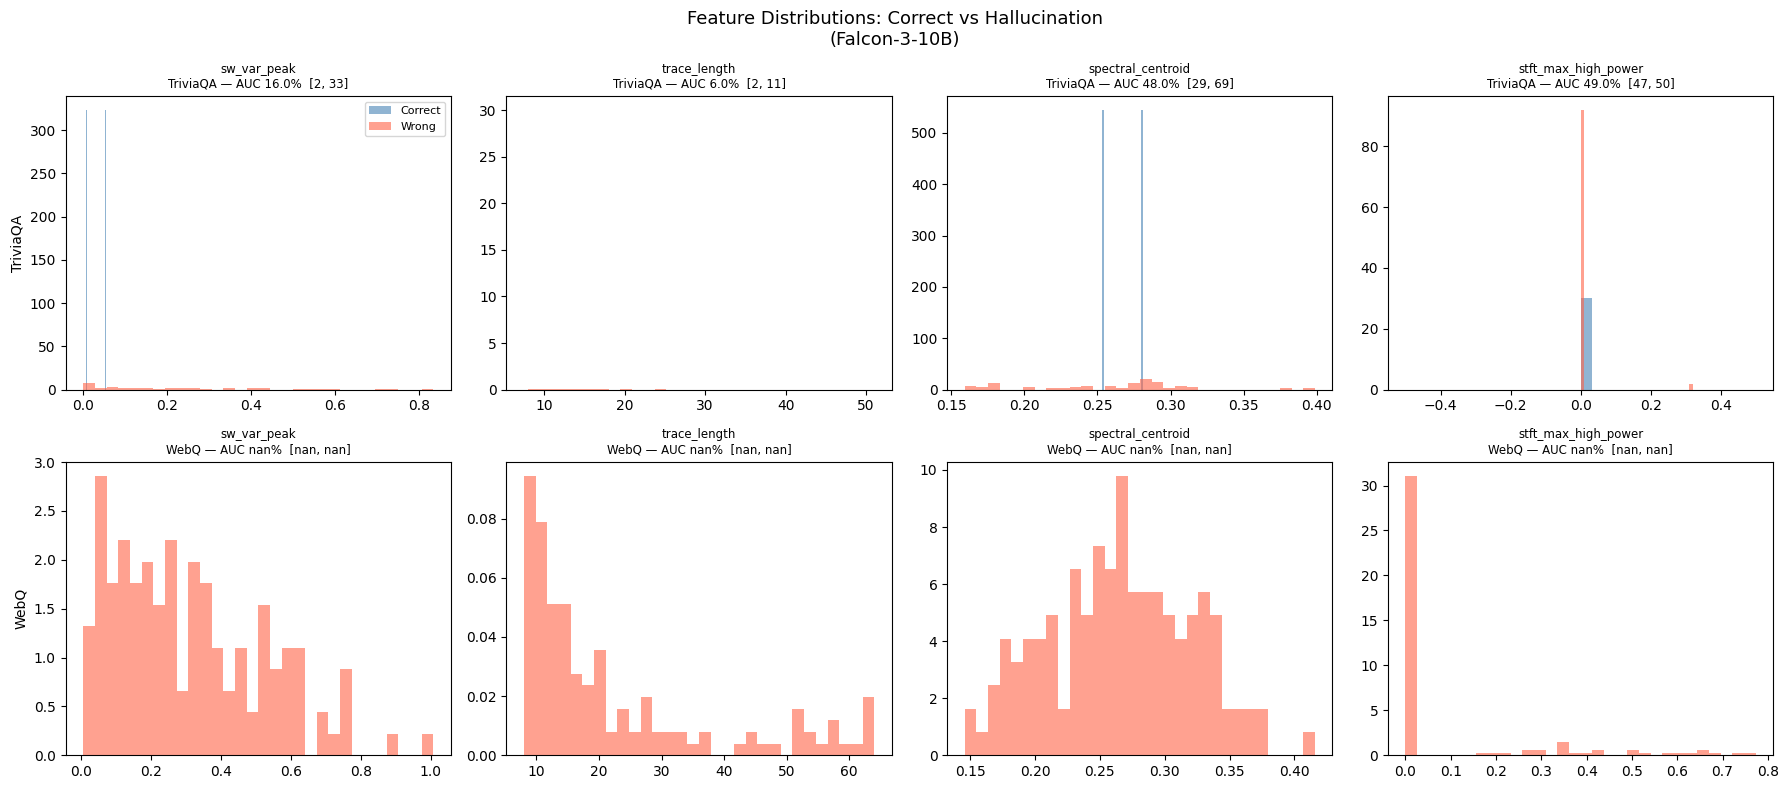

In [9]:
# Cell 9 — Feature behavior: distributions by correctness
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions: Correct vs Hallucination\n(Falcon-3-10B)', fontsize=13)

for col_idx, feat in enumerate(FIXED_SUBSET):
    for row_idx, (df, labels, dname) in enumerate([
        (trivia_df, trivia_labels, 'TriviaQA'),
        (webq_df,   webq_labels,   'WebQ'),
    ]):
        ax = axes[row_idx, col_idx]
        correct_vals = df[feat][labels == 1].values
        wrong_vals   = df[feat][labels == 0].values
        ax.hist(correct_vals, bins=30, alpha=0.6, color='steelblue', label='Correct', density=True)
        ax.hist(wrong_vals,   bins=30, alpha=0.6, color='tomato',    label='Wrong',   density=True)
        auc, lo, hi = boot_auc(labels, df[feat].values)
        ax.set_title(f'{feat}\n{dname} — AUC {100*auc:.1f}%  [{100*lo:.0f}, {100*hi:.0f}]',
                     fontsize=8.5)
        if col_idx == 0:
            ax.set_ylabel(dname, fontsize=10)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/feature_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap

We validate that the 4 selected features remain decorrelated on new domains.
Nadler fusion works best when pairwise Spearman |ρ| < 0.75 for all pairs in the subset.

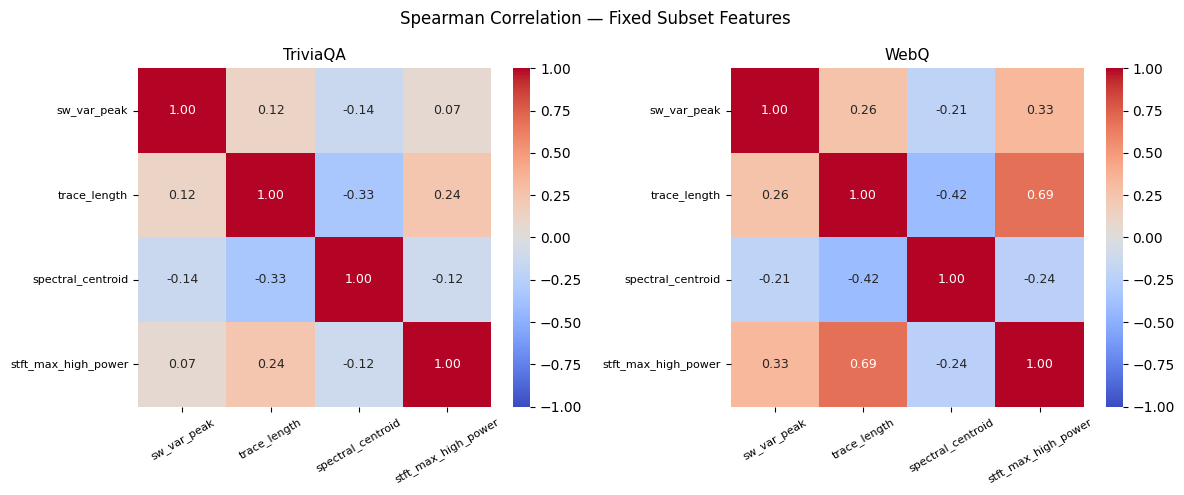

Black borders = |rho| >= 0.75 (Nadler threshold).


In [10]:
# Cell 10 — Spearman correlation heatmap for fixed subset
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Spearman Correlation — Fixed Subset Features', fontsize=12)

for ax, (df, dname) in zip(axes, [(trivia_df, 'TriviaQA'), (webq_df, 'WebQ')]):
    n = len(FIXED_SUBSET)
    corr_mat = np.zeros((n, n))
    for i, f1 in enumerate(FIXED_SUBSET):
        for j, f2 in enumerate(FIXED_SUBSET):
            r, _ = spearmanr(df[f1].values, df[f2].values)
            corr_mat[i, j] = r
    sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=FIXED_SUBSET, yticklabels=FIXED_SUBSET, ax=ax,
                annot_kws={'size': 9})
    ax.set_title(dname, fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    # Annotate pairs that exceed the Nadler threshold
    for i in range(n):
        for j in range(n):
            if i != j and abs(corr_mat[i, j]) >= 0.75:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2))

plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Black borders = |rho| >= 0.75 (Nadler threshold).')

## Window Ablation

We test `sw_var_peak` AUC across a range of window sizes for short QA traces,
plus the adaptive window (≈10% of trace length, clipped to [3, 32]).

For math traces (~1000 tokens), w=16 was optimal. For QA traces (~50–100 tokens),
w=16 covers 16–32% of the trace — potentially too coarse.

In [11]:
# Cell 11 — Window ablation: AUC for each window size + adaptive
# NOTE: pass valid_results (filtered), not the full results list, to keep
# lengths aligned with the labels array produced by extract_dataset_features.
def window_ablation(results, labels, window_sizes, dataset_name):
    """results and labels must be aligned (same filtered set from extract_dataset_features)."""
    aucs = {}
    for w in window_sizes:
        scores = np.array([sw_var_peak_with_window(r['ents'], w) for r in results])
        auc, lo, hi = boot_auc(labels, scores)
        aucs[w] = (auc, lo, hi)
        print(f'  {dataset_name}  w={w:2d}: AUC={100*auc:.1f}%  CI=[{100*lo:.1f}, {100*hi:.1f}]')
    adaptive_scores = np.array([sw_var_peak_adaptive(r['ents']) for r in results])
    auc_a, lo_a, hi_a = boot_auc(labels, adaptive_scores)
    trace_lens = [len(r['ents']) for r in results]
    median_w   = max(3, min(32, int(np.median(trace_lens) * 0.10)))
    print(f'  {dataset_name}  adaptive (median_w≈{median_w}): '
          f'AUC={100*auc_a:.1f}%  CI=[{100*lo_a:.1f}, {100*hi_a:.1f}]')
    return aucs, (auc_a, lo_a, hi_a), median_w

print('=== TriviaQA (direct answer) ===')
trivia_window_aucs, trivia_adaptive, trivia_median_w = window_ablation(
    trivia_valid, trivia_labels, WINDOW_SIZES, 'TriviaQA')

print('\n=== WebQ (direct answer) ===')
webq_window_aucs, webq_adaptive, webq_median_w = window_ablation(
    webq_valid, webq_labels, WINDOW_SIZES, 'WebQ')

=== TriviaQA (direct answer) ===
  TriviaQA  w= 3: AUC=16.0%  CI=[2.0, 33.3]
  TriviaQA  w= 5: AUC=16.0%  CI=[2.0, 33.3]
  TriviaQA  w= 7: AUC=15.0%  CI=[2.0, 31.4]
  TriviaQA  w= 9: AUC=15.0%  CI=[2.0, 31.4]
  TriviaQA  w=12: AUC=16.0%  CI=[2.0, 33.3]
  TriviaQA  w=16: AUC=16.0%  CI=[2.0, 33.3]
  TriviaQA  w=24: AUC=16.0%  CI=[2.0, 33.3]
  TriviaQA  w=32: AUC=16.0%  CI=[2.0, 33.3]
  TriviaQA  adaptive (median_w≈3): AUC=16.0%  CI=[2.0, 33.3]

=== WebQ (direct answer) ===
  WebQ  w= 3: AUC=nan%  CI=[nan, nan]
  WebQ  w= 5: AUC=nan%  CI=[nan, nan]
  WebQ  w= 7: AUC=nan%  CI=[nan, nan]
  WebQ  w= 9: AUC=nan%  CI=[nan, nan]
  WebQ  w=12: AUC=nan%  CI=[nan, nan]
  WebQ  w=16: AUC=nan%  CI=[nan, nan]
  WebQ  w=24: AUC=nan%  CI=[nan, nan]
  WebQ  w=32: AUC=nan%  CI=[nan, nan]
  WebQ  adaptive (median_w≈3): AUC=nan%  CI=[nan, nan]


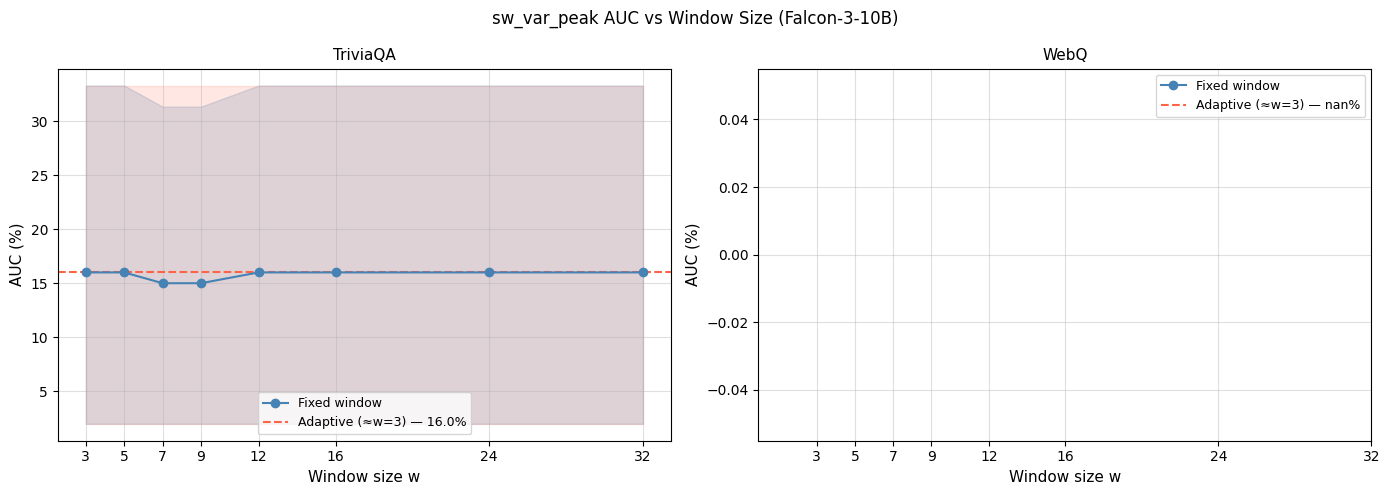

In [12]:
# Cell 12 — Plot window ablation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('sw_var_peak AUC vs Window Size (Falcon-3-10B)', fontsize=12)

for ax, (window_aucs, adaptive, median_w, dname) in zip(axes, [
    (trivia_window_aucs, trivia_adaptive, trivia_median_w, 'TriviaQA'),
    (webq_window_aucs,   webq_adaptive,   webq_median_w,   'WebQ'),
]):
    ws   = list(window_aucs.keys())
    aucs = [window_aucs[w][0] * 100 for w in ws]
    los  = [window_aucs[w][1] * 100 for w in ws]
    his  = [window_aucs[w][2] * 100 for w in ws]

    ax.plot(ws, aucs, 'o-', color='steelblue', label='Fixed window', zorder=3)
    ax.fill_between(ws, los, his, alpha=0.2, color='steelblue')

    auc_a = adaptive[0] * 100
    lo_a  = adaptive[1] * 100
    hi_a  = adaptive[2] * 100
    ax.axhline(auc_a, color='tomato', linestyle='--',
               label=f'Adaptive (≈w={median_w}) — {auc_a:.1f}%')
    ax.fill_between([ws[0], ws[-1]], [lo_a, lo_a], [hi_a, hi_a],
                    alpha=0.15, color='tomato')

    ax.set_xlabel('Window size w', fontsize=11)
    ax.set_ylabel('AUC (%)', fontsize=11)
    ax.set_title(dname, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xticks(ws)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/window_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## Fixed Subset Nadler Fusion

Apply the pre-selected 4-feature subset using Nadler fusion — **no new subset search**.
Sign orientation and z-scoring are applied before fusion (same as `best_nadler_on` internally).

In [13]:
# Cell 13 — Fixed subset fusion
def apply_fixed_subset(df, labels, subset, label=''):
    """Orient, z-score, and Nadler-fuse a pre-defined feature subset. No search."""
    feats_dict = {f: df[f].values for f in subset}

    # Orient: higher score → more likely correct
    signs = {}
    for f in subset:
        a_pos, *_ = boot_auc(labels,  feats_dict[f])
        a_neg, *_ = boot_auc(labels, -feats_dict[f])
        signs[f] = +1 if a_pos >= a_neg else -1

    oriented = {f: zscore(feats_dict[f] * signs[f]) for f in subset}

    fused_nadler, weights = nadler_fuse(*[oriented[f] for f in subset])
    auc_n, lo_n, hi_n    = boot_auc(labels, fused_nadler)

    fused_mean, _ = simple_average_fusion(*[oriented[f] for f in subset])
    auc_m, lo_m, hi_m = boot_auc(labels, fused_mean)

    print(f'\n=== Fixed Subset Fusion [{label}] ===')
    print(f'Subset: {" + ".join(subset)}\n')
    for f, w, s in zip(subset, weights, [signs[f] for f in subset]):
        a, *_ = boot_auc(labels, feats_dict[f])
        print(f'  {f:<30}  indiv AUC={100*a:.1f}%  Nadler weight={w:.3f}  sign={s:+d}')
    print(f'\n  Nadler  : {100*auc_n:.1f}%  [{100*lo_n:.1f}, {100*hi_n:.1f}]')
    print(f'  Mean    : {100*auc_m:.1f}%  [{100*lo_m:.1f}, {100*hi_m:.1f}]')
    print(f'  Lift    : {(auc_n - auc_m)*100:+.1f} pp')
    return auc_n, lo_n, hi_n, auc_m, lo_m, hi_m

trivia_nadler_auc, trivia_nadler_lo, trivia_nadler_hi, trivia_mean_auc, _, _ = apply_fixed_subset(
    trivia_df, trivia_labels, FIXED_SUBSET, label='TriviaQA')

webq_nadler_auc, webq_nadler_lo, webq_nadler_hi, webq_mean_auc, _, _ = apply_fixed_subset(
    webq_df, webq_labels, FIXED_SUBSET, label='WebQ')


=== Fixed Subset Fusion [TriviaQA] ===
Subset: sw_var_peak + trace_length + spectral_centroid + stft_max_high_power

  sw_var_peak                     indiv AUC=16.0%  Nadler weight=0.003  sign=-1
  trace_length                    indiv AUC=6.0%  Nadler weight=0.398  sign=-1
  spectral_centroid               indiv AUC=48.0%  Nadler weight=0.094  sign=-1
  stft_max_high_power             indiv AUC=49.0%  Nadler weight=0.506  sign=-1

  Nadler  : 93.0%  [84.3, 99.0]
  Mean    : 87.0%  [75.1, 96.1]
  Lift    : +6.0 pp

=== Fixed Subset Fusion [WebQ] ===
Subset: sw_var_peak + trace_length + spectral_centroid + stft_max_high_power

  sw_var_peak                     indiv AUC=nan%  Nadler weight=0.003  sign=-1
  trace_length                    indiv AUC=nan%  Nadler weight=0.422  sign=-1
  spectral_centroid               indiv AUC=nan%  Nadler weight=0.081  sign=-1
  stft_max_high_power             indiv AUC=nan%  Nadler weight=0.494  sign=-1

  Nadler  : nan%  [nan, nan]
  Mean    : nan%  

## Baseline Comparison and Summary

We compare the fixed subset fusion against:
- **EPR baseline** (`epr` feature = mean token entropy) — the standard single-feature EPR score
- **Individual features** from the fixed subset
- **Adaptive `sw_var_peak`** alone

Reference numbers from prior work (Falcon-3-10B, `direct_fresh`, `Unified_EPR_Ensemble_res.ipynb`):
- TriviaQA EPR: **72.0%**
- WebQ EPR: **66.4%**

In [14]:
# Cell 14 — Baseline comparison table
rows = []

signals = [
    ('epr',                 'EPR (mean entropy)'),
    ('sw_var_peak',         'sw_var_peak  w=16'),
    ('trace_length',        'trace_length'),
    ('spectral_centroid',   'spectral_centroid'),
    ('stft_max_high_power', 'stft_max_high_power'),
]

for feat, label in signals:
    ta, tlo, thi = boot_auc(trivia_labels, trivia_df[feat].values)
    wa, wlo, whi = boot_auc(webq_labels,   webq_df[feat].values)
    rows.append({'Signal': label,
                 'TriviaQA AUC': f'{100*ta:.1f}%',
                 'WebQ AUC':     f'{100*wa:.1f}%'})

# Adaptive sw_var_peak
ta_a, *_ = boot_auc(trivia_labels,
                    np.array([sw_var_peak_adaptive(r['ents']) for r in trivia_results]))
wa_a, *_ = boot_auc(webq_labels,
                    np.array([sw_var_peak_adaptive(r['ents']) for r in webq_results]))
rows.append({'Signal': 'sw_var_peak  adaptive',
             'TriviaQA AUC': f'{100*ta_a:.1f}%',
             'WebQ AUC':     f'{100*wa_a:.1f}%'})

rows.append({'Signal': '--- fusion ---', 'TriviaQA AUC': '', 'WebQ AUC': ''})
rows.append({'Signal': 'Fixed 4-feat Nadler',
             'TriviaQA AUC': f'{100*trivia_nadler_auc:.1f}%  [{100*trivia_nadler_lo:.0f}, {100*trivia_nadler_hi:.0f}]',
             'WebQ AUC':     f'{100*webq_nadler_auc:.1f}%  [{100*webq_nadler_lo:.0f}, {100*webq_nadler_hi:.0f}]'})
rows.append({'Signal': 'Fixed 4-feat Mean',
             'TriviaQA AUC': f'{100*trivia_mean_auc:.1f}%',
             'WebQ AUC':     f'{100*webq_mean_auc:.1f}%'})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

epr_trivia, *_ = boot_auc(trivia_labels, trivia_df['epr'].values)
epr_webq,   *_ = boot_auc(webq_labels,   webq_df['epr'].values)
print(f'\nNadler lift over EPR baseline:')
print(f'  TriviaQA: {(trivia_nadler_auc - epr_trivia)*100:+.1f} pp  '
      f'(ref EPR direct_fresh = 72.0% from Unified_EPR_Ensemble_res)')
print(f'  WebQ:     {(webq_nadler_auc - epr_webq)*100:+.1f} pp  '
      f'(ref EPR direct_fresh = 66.4% from Unified_EPR_Ensemble_res)')

ValueError: Found input variables with inconsistent numbers of samples: [52, 300]

ValueError: Found input variables with inconsistent numbers of samples: [52, 300]

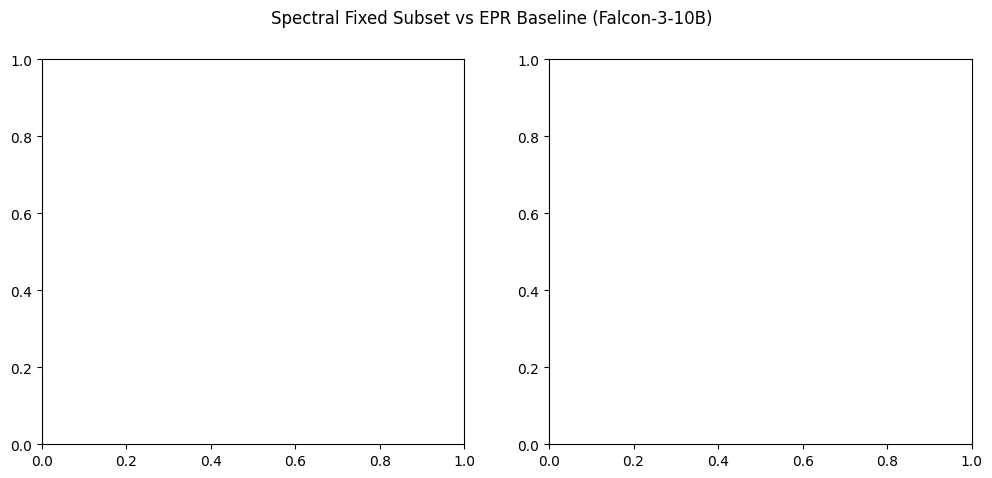

In [15]:
# Cell 15 — Bar chart: fixed subset vs EPR baseline
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Spectral Fixed Subset vs EPR Baseline (Falcon-3-10B)', fontsize=12)

bar_labels = ['EPR\n(mean entropy)', 'sw_var_peak\nw=16', 'sw_var_peak\nadaptive',
              'Fixed 4-feat\nMean fusion', 'Fixed 4-feat\nNadler fusion']

for ax, (df, labels, results, nadler_a, mean_a, dname) in zip(axes, [
    (trivia_df, trivia_labels, trivia_results, trivia_nadler_auc, trivia_mean_auc, 'TriviaQA'),
    (webq_df,   webq_labels,   webq_results,   webq_nadler_auc,   webq_mean_auc,   'WebQ'),
]):
    epr_a,  *_ = boot_auc(labels, df['epr'].values)
    sw_a,   *_ = boot_auc(labels, df['sw_var_peak'].values)
    adap_a, *_ = boot_auc(labels,
                           np.array([sw_var_peak_adaptive(r['ents']) for r in results]))
    aucs   = [epr_a * 100, sw_a * 100, adap_a * 100, mean_a * 100, nadler_a * 100]
    colors = ['#aaaaaa', '#6baed6', '#3182bd', '#fdae6b', '#e6550d']
    bars   = ax.bar(bar_labels, aucs, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_ylim(max(0, min(aucs) - 5), min(100, max(aucs) + 5))
    ax.set_ylabel('AUC (%)', fontsize=11)
    ax.set_title(dname, fontsize=11)
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 2 — Chain-of-Thought Prompting

**Problem identified in Part 1:** Direct-answer QA generates traces that are too short for spectral analysis (1–10 tokens per response). On TriviaQA, 83% of traces were discarded; on WebQ, 55% — and after filtering, the surviving sets had near-zero positive rate (3.8% and 0.0% correct), making AUC computation meaningless.

**Fix:** CoT prompting forces the model to reason step-by-step before stating its final answer, producing 50–256 token generation traces that are amenable to FFT-based spectral features. This is the same regime in which the features were originally discovered (GSM8K, GPQA — both inherently CoT tasks).

**Grading:** Same normalized exact-match as Part 1, but the answer is extracted from the last `Answer:` line of the CoT response.

**Sections:**
- Reload model
- CoT prompt templates and answer extraction helper
- TriviaQA CoT inference (with checkpointing)
- WebQ CoT inference (with checkpointing)
- Feature extraction + trace length comparison
- Window ablation for CoT traces
- Fixed 4-feature Nadler fusion for CoT

In [16]:
# Cell P2-2 — Reload model for CoT inference
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)
print('Model reloaded for Part 2 (CoT).')

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

Loaded tiiuae/Falcon3-10B-Instruct
Model reloaded for Part 2 (CoT).


In [17]:
# Cell P2-3 — CoT prompt templates and answer extraction
MAX_TOKENS_COT = 256  # room for step-by-step reasoning + final answer line

def trivia_qa_cot_prompt(question):
    return (
        "Answer the following question. Think through your reasoning step by step, "
        "then state your final answer on its own line starting with 'Answer:'.\n\n"
        f"Question: {question}\n\n"
        "Let me think step by step:"
    )

def webq_cot_prompt(question):
    return (
        "Answer the following question. Think through your reasoning step by step, "
        "then state your final answer on its own line starting with 'Answer:'.\n\n"
        f"Question: {question}\n\n"
        "Let me think step by step:"
    )

def extract_cot_answer(text):
    """Extract answer from last 'Answer:' line. Fallback: last non-empty line."""
    for line in reversed(text.strip().split('\n')):
        stripped = line.strip()
        if stripped.lower().startswith('answer:'):
            return stripped[len('answer:'):].strip()
    for line in reversed(text.strip().split('\n')):
        if line.strip():
            return line.strip()
    return text.strip()

print('CoT helpers ready. MAX_TOKENS_COT =', MAX_TOKENS_COT)

CoT helpers ready. MAX_TOKENS_COT = 256


In [18]:
# Cell P2-4 — TriviaQA CoT inference (with checkpointing)
TRIVIA_COT_CACHE = f'{CACHE_DIR}/trivia_qa_cot_traces.pkl'

trivia_cot_results = load_cache(TRIVIA_COT_CACHE) or []
start_idx = len(trivia_cot_results)
print(f'TriviaQA CoT: resuming from {start_idx}/{N_SAMPLES}')

for i, item in enumerate(trivia_items[start_idx:], start=start_idx):
    prompt = trivia_qa_cot_prompt(item['question'])
    text, ents = generate_full(mdl, tok, prompt,
                               temperature=TEMPERATURE, max_new_tokens=MAX_TOKENS_COT)
    answer  = extract_cot_answer(text)
    correct = is_correct_trivia_qa(answer, item)
    trivia_cot_results.append({
        'text': text, 'ents': ents, 'correct': correct,
        'item': item, 'extracted_answer': answer,
    })
    if (i + 1) % 25 == 0:
        save_cache(trivia_cot_results, TRIVIA_COT_CACHE)
        acc = np.mean([r['correct'] for r in trivia_cot_results])
        print(f'  {i+1}/{N_SAMPLES}  acc={acc:.1%}')

save_cache(trivia_cot_results, TRIVIA_COT_CACHE)
trivia_cot_acc = np.mean([r['correct'] for r in trivia_cot_results])
print(f'\nTriviaQA CoT done. Acc={trivia_cot_acc:.1%}  '
      f'({sum(r["correct"] for r in trivia_cot_results)}/{len(trivia_cot_results)} correct)')

TriviaQA CoT: resuming from 0/300
  25/300  acc=24.0%
  50/300  acc=36.0%
  75/300  acc=29.3%
  100/300  acc=28.0%
  125/300  acc=24.0%
  150/300  acc=24.0%
  175/300  acc=25.1%
  200/300  acc=23.0%
  225/300  acc=25.3%
  250/300  acc=26.4%
  275/300  acc=27.6%
  300/300  acc=28.3%

TriviaQA CoT done. Acc=28.3%  (85/300 correct)


In [19]:
# Cell P2-5 — WebQ CoT inference (with checkpointing)
WEBQ_COT_CACHE = f'{CACHE_DIR}/webq_cot_traces.pkl'

webq_cot_results = load_cache(WEBQ_COT_CACHE) or []
start_idx = len(webq_cot_results)
print(f'WebQ CoT: resuming from {start_idx}/{N_SAMPLES}')

for i, item in enumerate(webq_items[start_idx:], start=start_idx):
    prompt = webq_cot_prompt(item['question'])
    text, ents = generate_full(mdl, tok, prompt,
                               temperature=TEMPERATURE, max_new_tokens=MAX_TOKENS_COT)
    answer  = extract_cot_answer(text)
    correct = is_correct_webq(answer, item)
    webq_cot_results.append({
        'text': text, 'ents': ents, 'correct': correct,
        'item': item, 'extracted_answer': answer,
    })
    if (i + 1) % 25 == 0:
        save_cache(webq_cot_results, WEBQ_COT_CACHE)
        acc = np.mean([r['correct'] for r in webq_cot_results])
        print(f'  {i+1}/{N_SAMPLES}  acc={acc:.1%}')

save_cache(webq_cot_results, WEBQ_COT_CACHE)
webq_cot_acc = np.mean([r['correct'] for r in webq_cot_results])
print(f'\nWebQ CoT done. Acc={webq_cot_acc:.1%}  '
      f'({sum(r["correct"] for r in webq_cot_results)}/{len(webq_cot_results)} correct)')

WebQ CoT: resuming from 0/300
  25/300  acc=16.0%
  50/300  acc=10.0%
  75/300  acc=17.3%
  100/300  acc=18.0%
  125/300  acc=15.2%
  150/300  acc=15.3%
  175/300  acc=14.3%
  200/300  acc=14.5%
  225/300  acc=14.7%
  250/300  acc=14.4%
  275/300  acc=13.8%
  300/300  acc=12.7%

WebQ CoT done. Acc=12.7%  (38/300 correct)


In [20]:
# Cell P2-6 — Unload model (Part 2)
del mdl, tok
free_memory()
print('Model unloaded.')

Model unloaded.


In [21]:
# Cell P2-7 — CoT feature extraction + trace length summary
trivia_cot_df, trivia_cot_labels, trivia_cot_valid = extract_dataset_features(trivia_cot_results)
webq_cot_df,   webq_cot_labels,   webq_cot_valid   = extract_dataset_features(webq_cot_results)

print(f'TriviaQA CoT: {len(trivia_cot_df)} samples, {trivia_cot_labels.mean():.1%} correct')
print(f'WebQ CoT:     {len(webq_cot_df)} samples, {webq_cot_labels.mean():.1%} correct')
print()

# Trace length comparison: direct vs CoT
print('Trace length comparison (all 300 samples):')
for tag, results, valid in [
    ('TriviaQA direct', trivia_results,     trivia_valid),
    ('TriviaQA CoT',   trivia_cot_results,  trivia_cot_valid),
    ('WebQ direct',    webq_results,         webq_valid),
    ('WebQ CoT',       webq_cot_results,     webq_cot_valid),
]:
    all_lens   = [len(r['ents']) for r in results]
    valid_lens = [len(r['ents']) for r in valid]
    med_valid  = np.median(valid_lens) if valid_lens else 0
    print(f'  {tag:<22}  median_all={np.median(all_lens):.0f}  '
          f'valid={len(valid)}/{len(results)}  '
          f'median_valid={med_valid:.0f}')

  Skipped 15 traces (too short for spectral analysis)
  Skipped 10 traces (too short for spectral analysis)
TriviaQA CoT: 285 samples, 27.7% correct
WebQ CoT:     290 samples, 11.4% correct

Trace length comparison (all 300 samples):
  TriviaQA direct         median_all=4  valid=52/300  median_valid=14
  TriviaQA CoT            median_all=49  valid=285/300  median_valid=50
  WebQ direct             median_all=6  valid=136/300  median_valid=15
  WebQ CoT                median_all=51  valid=290/300  median_valid=52


In [22]:
# Cell P2-8 — Window ablation for CoT traces
print('=== TriviaQA CoT ===')
trivia_cot_window_aucs, trivia_cot_adaptive, trivia_cot_median_w = window_ablation(
    trivia_cot_valid, trivia_cot_labels, WINDOW_SIZES, 'TriviaQA CoT')

print('\n=== WebQ CoT ===')
webq_cot_window_aucs, webq_cot_adaptive, webq_cot_median_w = window_ablation(
    webq_cot_valid, webq_cot_labels, WINDOW_SIZES, 'WebQ CoT')

=== TriviaQA CoT ===
  TriviaQA CoT  w= 3: AUC=31.5%  CI=[24.3, 38.3]
  TriviaQA CoT  w= 5: AUC=31.6%  CI=[24.2, 38.2]
  TriviaQA CoT  w= 7: AUC=33.2%  CI=[25.9, 39.8]
  TriviaQA CoT  w= 9: AUC=35.1%  CI=[27.3, 41.9]
  TriviaQA CoT  w=12: AUC=34.4%  CI=[26.5, 41.6]
  TriviaQA CoT  w=16: AUC=34.6%  CI=[26.6, 41.7]
  TriviaQA CoT  w=24: AUC=34.6%  CI=[26.8, 41.3]
  TriviaQA CoT  w=32: AUC=33.6%  CI=[26.1, 40.4]
  TriviaQA CoT  adaptive (median_w≈5): AUC=31.5%  CI=[24.2, 38.4]

=== WebQ CoT ===
  WebQ CoT  w= 3: AUC=36.0%  CI=[27.8, 44.9]
  WebQ CoT  w= 5: AUC=33.4%  CI=[25.7, 41.5]
  WebQ CoT  w= 7: AUC=34.9%  CI=[26.0, 43.9]
  WebQ CoT  w= 9: AUC=36.1%  CI=[26.9, 45.4]
  WebQ CoT  w=12: AUC=36.4%  CI=[27.0, 46.1]
  WebQ CoT  w=16: AUC=36.4%  CI=[26.2, 45.9]
  WebQ CoT  w=24: AUC=35.6%  CI=[25.5, 44.9]
  WebQ CoT  w=32: AUC=37.2%  CI=[26.7, 46.4]
  WebQ CoT  adaptive (median_w≈5): AUC=39.6%  CI=[30.0, 49.0]


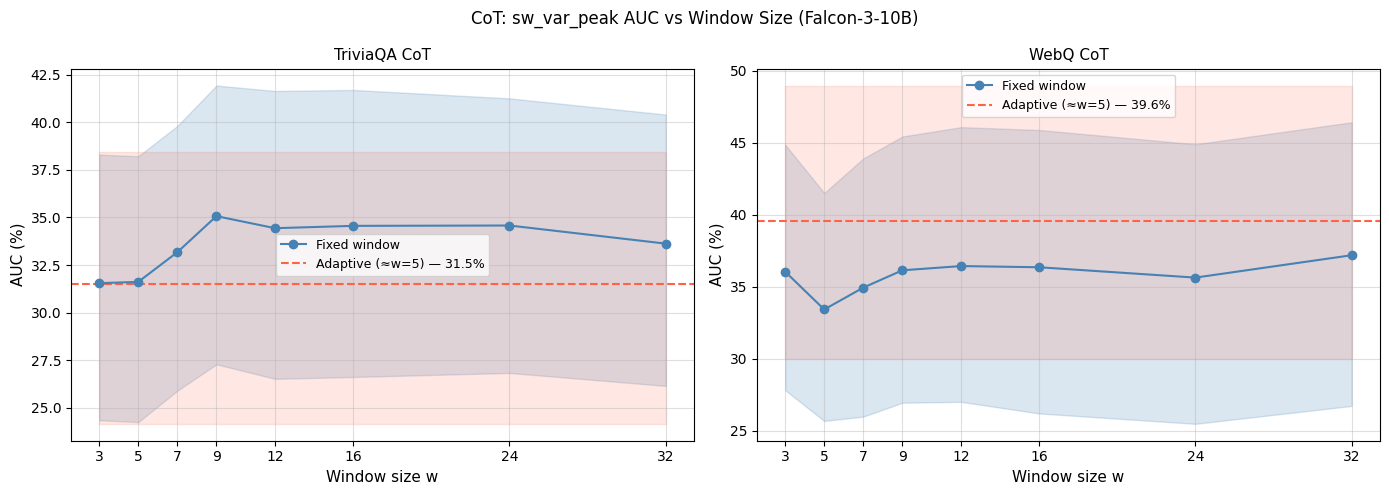

In [23]:
# Cell P2-9 — Plot CoT window ablation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CoT: sw_var_peak AUC vs Window Size (Falcon-3-10B)', fontsize=12)

for ax, (window_aucs, adaptive, median_w, dname) in zip(axes, [
    (trivia_cot_window_aucs, trivia_cot_adaptive, trivia_cot_median_w, 'TriviaQA CoT'),
    (webq_cot_window_aucs,   webq_cot_adaptive,   webq_cot_median_w,   'WebQ CoT'),
]):
    ws   = list(window_aucs.keys())
    aucs = [window_aucs[w][0] * 100 for w in ws]
    los  = [window_aucs[w][1] * 100 for w in ws]
    his  = [window_aucs[w][2] * 100 for w in ws]

    ax.plot(ws, aucs, 'o-', color='steelblue', label='Fixed window', zorder=3)
    ax.fill_between(ws, los, his, alpha=0.2, color='steelblue')

    auc_a = adaptive[0] * 100
    lo_a  = adaptive[1] * 100
    hi_a  = adaptive[2] * 100
    ax.axhline(auc_a, color='tomato', linestyle='--',
               label=f'Adaptive (≈w={median_w}) — {auc_a:.1f}%')
    ax.fill_between([ws[0], ws[-1]], [lo_a, lo_a], [hi_a, hi_a], alpha=0.15, color='tomato')

    ax.set_xlabel('Window size w', fontsize=11)
    ax.set_ylabel('AUC (%)', fontsize=11)
    ax.set_title(dname, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xticks(ws)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/cot_window_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Cell P2-10 — Fixed subset Nadler fusion for CoT results
trivia_cot_nadler_auc, trivia_cot_nadler_lo, trivia_cot_nadler_hi, trivia_cot_mean_auc, _, _ = \
    apply_fixed_subset(trivia_cot_df, trivia_cot_labels, FIXED_SUBSET, label='TriviaQA CoT')

webq_cot_nadler_auc, webq_cot_nadler_lo, webq_cot_nadler_hi, webq_cot_mean_auc, _, _ = \
    apply_fixed_subset(webq_cot_df, webq_cot_labels, FIXED_SUBSET, label='WebQ CoT')


=== Fixed Subset Fusion [TriviaQA CoT] ===
Subset: sw_var_peak + trace_length + spectral_centroid + stft_max_high_power

  sw_var_peak                     indiv AUC=34.6%  Nadler weight=0.052  sign=-1
  trace_length                    indiv AUC=47.5%  Nadler weight=0.334  sign=-1
  spectral_centroid               indiv AUC=47.7%  Nadler weight=0.200  sign=-1
  stft_max_high_power             indiv AUC=48.6%  Nadler weight=0.415  sign=-1

  Nadler  : 53.6%  [46.5, 61.6]
  Mean    : 59.5%  [52.3, 67.2]
  Lift    : -5.9 pp

=== Fixed Subset Fusion [WebQ CoT] ===
Subset: sw_var_peak + trace_length + spectral_centroid + stft_max_high_power

  sw_var_peak                     indiv AUC=36.4%  Nadler weight=0.028  sign=-1
  trace_length                    indiv AUC=40.0%  Nadler weight=0.436  sign=-1
  spectral_centroid               indiv AUC=49.0%  Nadler weight=0.079  sign=-1
  stft_max_high_power             indiv AUC=40.1%  Nadler weight=0.457  sign=-1

  Nadler  : 61.9%  [51.7, 72.1]
  

---

## Part 2 vs Part 1 — Direct-Answer vs CoT Comparison

Key question: **does forcing longer traces via CoT unlock the spectral features?**

We compare across both prompting styles on the same 300 samples:
- Model accuracy (how often it gets the right answer)
- Trace survival rate (how many traces are long enough for FFT)
- Class balance in the valid set (% correct — drives AUC feasibility)
- EPR AUC and Nadler 4-feature AUC on the valid set

In [25]:
# Cell P2-12 — Head-to-head comparison table: Direct vs CoT
trivia_acc_full = np.mean([r['correct'] for r in trivia_results])
webq_acc_full   = np.mean([r['correct'] for r in webq_results])

def fmt(auc, lo=None, hi=None):
    if np.isnan(auc):
        return 'N/A (single class)'
    s = f'{100*auc:.1f}%'
    if lo is not None and not np.isnan(lo):
        s += f'  [{100*lo:.0f},{100*hi:.0f}]'
    return s

n = N_SAMPLES
rows = []

rows.append({'Metric': 'Model accuracy (all 300)',
             'TriviaQA Direct': f'{trivia_acc_full:.1%}',
             'TriviaQA CoT':    f'{trivia_cot_acc:.1%}',
             'WebQ Direct':     f'{webq_acc_full:.1%}',
             'WebQ CoT':        f'{webq_cot_acc:.1%}'})

rows.append({'Metric': 'Traces surviving FFT',
             'TriviaQA Direct': f'{len(trivia_valid)}/{n}  ({100*len(trivia_valid)/n:.0f}%)',
             'TriviaQA CoT':    f'{len(trivia_cot_valid)}/{n}  ({100*len(trivia_cot_valid)/n:.0f}%)',
             'WebQ Direct':     f'{len(webq_valid)}/{n}  ({100*len(webq_valid)/n:.0f}%)',
             'WebQ CoT':        f'{len(webq_cot_valid)}/{n}  ({100*len(webq_cot_valid)/n:.0f}%)'})

rows.append({'Metric': '% correct in valid set',
             'TriviaQA Direct': f'{trivia_labels.mean():.1%}' if len(trivia_labels) else 'N/A',
             'TriviaQA CoT':    f'{trivia_cot_labels.mean():.1%}' if len(trivia_cot_labels) else 'N/A',
             'WebQ Direct':     f'{webq_labels.mean():.1%}' if len(webq_labels) else 'N/A',
             'WebQ CoT':        f'{webq_cot_labels.mean():.1%}' if len(webq_cot_labels) else 'N/A'})

epr_ta,     *_ = boot_auc(trivia_labels,     trivia_df['epr'].values)
epr_wa,     *_ = boot_auc(webq_labels,       webq_df['epr'].values)
epr_cot_ta, *_ = boot_auc(trivia_cot_labels, trivia_cot_df['epr'].values)
epr_cot_wa, *_ = boot_auc(webq_cot_labels,   webq_cot_df['epr'].values)

rows.append({'Metric': 'EPR AUC (valid set)',
             'TriviaQA Direct': fmt(epr_ta),
             'TriviaQA CoT':    fmt(epr_cot_ta),
             'WebQ Direct':     fmt(epr_wa),
             'WebQ CoT':        fmt(epr_cot_wa)})

rows.append({'Metric': 'Nadler 4-feat AUC',
             'TriviaQA Direct': fmt(trivia_nadler_auc, trivia_nadler_lo, trivia_nadler_hi),
             'TriviaQA CoT':    fmt(trivia_cot_nadler_auc, trivia_cot_nadler_lo, trivia_cot_nadler_hi),
             'WebQ Direct':     fmt(webq_nadler_auc, webq_nadler_lo, webq_nadler_hi),
             'WebQ CoT':        fmt(webq_cot_nadler_auc, webq_cot_nadler_lo, webq_cot_nadler_hi)})

df_compare = pd.DataFrame(rows)
print('=== Direct-Answer vs CoT — Head-to-Head ===\n')
print(df_compare.to_string(index=False))

=== Direct-Answer vs CoT — Head-to-Head ===

                  Metric TriviaQA Direct   TriviaQA CoT        WebQ Direct       WebQ CoT
Model accuracy (all 300)           30.0%          28.3%              15.0%          12.7%
    Traces surviving FFT   52/300  (17%) 285/300  (95%)     136/300  (45%) 290/300  (97%)
  % correct in valid set            3.8%          27.7%               0.0%          11.4%
     EPR AUC (valid set)           16.0%          34.0% N/A (single class)          38.7%
       Nadler 4-feat AUC  93.0%  [84,99] 53.6%  [47,62] N/A (single class) 61.9%  [52,72]


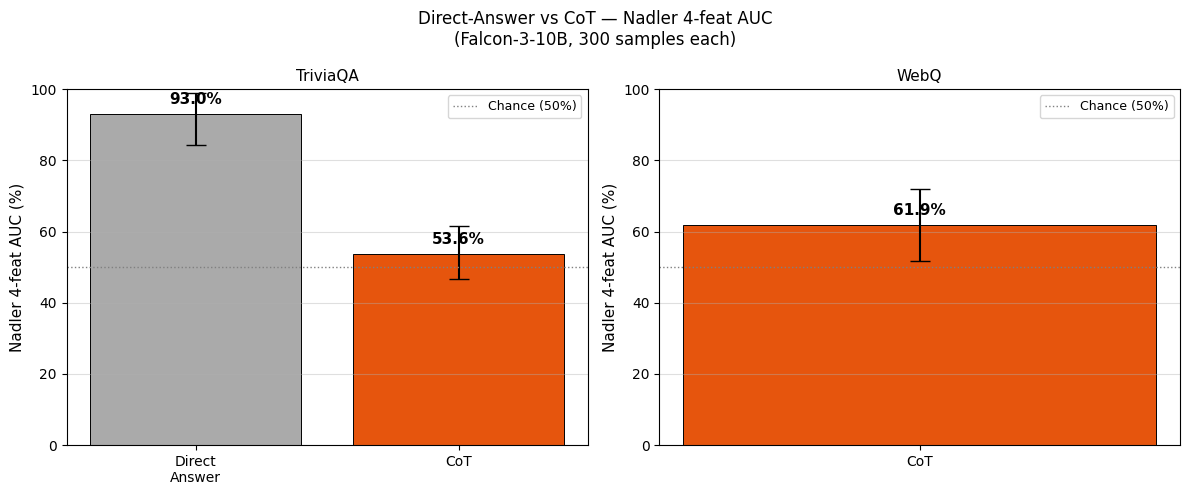

In [26]:
# Cell P2-13 — Comparison bar chart: Direct vs CoT Nadler AUC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Direct-Answer vs CoT — Nadler 4-feat AUC\n(Falcon-3-10B, 300 samples each)',
             fontsize=12)

for ax, (d_auc, d_lo, d_hi, c_auc, c_lo, c_hi, dname) in zip(axes, [
    (trivia_nadler_auc, trivia_nadler_lo, trivia_nadler_hi,
     trivia_cot_nadler_auc, trivia_cot_nadler_lo, trivia_cot_nadler_hi, 'TriviaQA'),
    (webq_nadler_auc, webq_nadler_lo, webq_nadler_hi,
     webq_cot_nadler_auc, webq_cot_nadler_lo, webq_cot_nadler_hi, 'WebQ'),
]):
    bar_labels = ['Direct\nAnswer', 'CoT']
    aucs_bar   = [d_auc * 100, c_auc * 100]
    errs_lo    = [(d_auc - d_lo) * 100, (c_auc - c_lo) * 100]
    errs_hi    = [(d_hi - d_auc) * 100, (c_hi - c_auc) * 100]
    colors = ['#aaaaaa', '#e6550d']

    bars = ax.bar(bar_labels, aucs_bar, color=colors, edgecolor='black', linewidth=0.7,
                  yerr=[errs_lo, errs_hi], capsize=7, error_kw={'linewidth': 1.5})
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, label='Chance (50%)')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Nadler 4-feat AUC (%)', fontsize=11)
    ax.set_title(dname, fontsize=11)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, aucs_bar):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/direct_vs_cot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()